In [49]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision import datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
%matplotlib inline

#torchvision 处理图像的工具箱


In [50]:
transform=T.ToTensor()

dataset=datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset=datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

图像 shape:torch.Size([1, 28, 28])
标签： 5


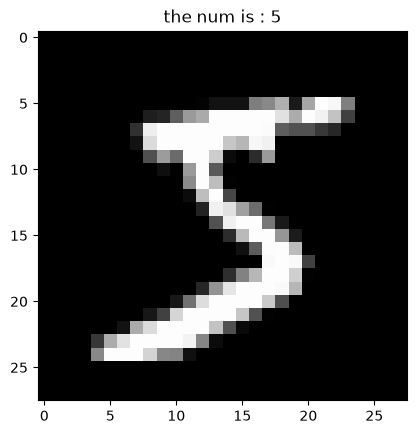

In [51]:
img,label=dataset[0]

print(f"图像 shape:{img.shape}")
print("标签：",label)

plt.imshow(img.squeeze(),cmap='gray')
plt.title(f"the num is : {label}")
plt.show()

In [52]:
train_dataset,val_dataset=torch.utils.data.random_split(dataset,[0.8,0.2])

train_loader=DataLoader(train_dataset,batch_size=64,shuffle=True)
val_loader =DataLoader(val_dataset,batch_size=64,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=64,shuffle=True)

In [53]:
class MLP(nn.Module):
    def __init__(self, layer_sizes):
        super().__init__()
        sz=layer_sizes
        self.layers=nn.ModuleList(
            [nn.Linear(sz[i],sz[i+1])
            for i in range(len(sz)-1)]
        )

    def forward (self,x):
        x=x.reshape(-1,28*28)
        for i , layer in enumerate(self.layers):
            x=layer(x)
            if i<len(self.layers)-1:
                x=F.relu(x)
        return x
model=MLP([784,256,256,10])


In [54]:
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001,weight_decay=0.001)

epochs=5

for epoch in range(epochs):
    #训练阶段
    loss_train=0
    for images,labels in train_loader:
        preds=model(images)
        loss=criterion(preds,labels)
        loss_train+=loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


    #验证阶段
    loss_val=0
    for images,labels in val_loader:
        with torch.no_grad():
            preds=model(images)
            loss=criterion(preds,labels)
            loss_val+=loss.item()


    print(f"Epoch {epoch}:train_loss={loss_train/len(train_loader):.4f},"
          f"val_loss={loss_val/len(val_loader):.4f}")



Epoch 0:train_loss=0.3162,val_loss=0.1503
Epoch 1:train_loss=0.1397,val_loss=0.1189
Epoch 2:train_loss=0.1082,val_loss=0.1030
Epoch 3:train_loss=0.0934,val_loss=0.1081
Epoch 4:train_loss=0.0846,val_loss=0.0919


In [55]:
correct=0
total=0

for images,labels in test_loader:
    with torch.no_grad():
        preds=model(images)
        _,predicted=torch.max(preds,1)
        total+=labels.size(0)
        correct+=(predicted==labels).sum().item()


print(f"测试集准确率：{correct/total *100:.2f}%")
    

测试集准确率：97.15%
